# Spectra of disordered vs. circulant ring-attractor weights

Builds two weight matrices with matched eigenvalue spectra, namely the model's `J` derived
from disordered tuning curves and a circulant matrix plus i.i.d. noise, and compares their
spectra and eigenvector structure. The point is that spectrum alone does not distinguish
the two; the eigenvector geometry does.

**Produces** Figure 6 (`figures/disordered_vs_circulant_spectra.pdf`).

**Reads** `data/spectra_cache.npz`, which stores the results of the expensive computations
and is recomputed from scratch if absent.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False

import numpy as np
from ring import fn, data_driven
from tqdm import tqdm
import matplotlib.pyplot as plt
from ring import style
from ring import regression
import scipy


## Idealized tuning-curve model

Local definitions for the idealized (non-data-driven) tuning-curve family: an erf nonlinearity, wrapped-Gaussian-covariance tuning curves, and the closed-form effective weight profile used to build the circulant comparison matrix.

In [2]:
from ring.tc import gen_tuning_curves_idealized

def nonlin_idealized_deriv_avg(data, beta):
    result = beta * fn.unity_erf_deriv(beta * data).mean()
    return result

def compute_eff_weights(beta, scale, lamda, N_theta):
    X, Phi = gen_tuning_curves_idealized(N_samples=50000, N_theta=N_theta, beta=beta, scale=scale)
    Gamma_x_ft = np.mean(np.abs(np.fft.fft(X, axis=0, norm='forward'))**2, 1)
    Gamma_phi_ft = np.mean(np.abs(np.fft.fft(Phi, axis=0, norm='forward'))**2, 1)
    # Mean-field weights in the N-normalized ridge convention (see the Notes of
    # regression.compute_J): Jhat_n = Ghat_x_n / (Ghat_phi_n + lamda). The same
    # lamda, in the same convention, as everywhere else in the codebase.
    J_ft = Gamma_x_ft / (Gamma_phi_ft + lamda)
    J = np.fft.ifft(J_ft, norm='forward').real
    J2 = np.fft.ifft(J_ft**2, norm='forward').real
    #also compute alpha
    alpha = nonlin_idealized_deriv_avg(data=X, beta=beta)
    return J, J2, J_ft, alpha


## DMFT effective weight profile

Computes the translation-invariant weight profile `J_dmft` and gain `alpha` from sampled tuning curves. The profile and the gain define the circulant matrix in the comparison below; the parameters (`beta`, `scale`) are the fitted values used throughout the paper.

In [3]:
import os

N = 2500
N_theta = 500
beta = 2.7659
scale = 1.4211
# TWO different constants, because they do two different jobs (see the lamda
# docstrings of regression.compute_J and dmft.DMFTModel).
#   lamda      is the ridge of the loss for the finite-N fit below, where it does
#              real work against the sampling structure of the empirical covariance.
#   lamda_dmft guards the CONTINUUM inversion in compute_eff_weights, which is exactly
#              singular because Ghat^phi_n -> 0 as n -> inf, so it should be as small as
#              the arithmetic allows and is not a model parameter.
# Switching the continuum guard from 1e-8 to 1e-12 moves the plotted top-11 eigenvalues
# by 1.9e-6 relative and real-space J by 2.8e-7, so this figure does not care; the
# consistency with dmft.py is the point.
lamda = 1e-8
lamda_dmft = 1e-12

# Cache the expensive deterministic computation. This cell's DMFT weight profile
# (50000 sampled tuning curves + FFTs) and the next cell's N x N eigen/SVD are
# all seeded and deterministic, so the cached arrays reproduce a fresh compute
# exactly. First run computes and writes the cache once; later runs just load it.
# Delete data/spectra_cache.npz to force a recompute.
SPECTRA_CACHE = "../data/spectra_cache.npz"

if os.path.exists(SPECTRA_CACHE):
    _cache = np.load(SPECTRA_CACHE)
    J_dmft = _cache['J_dmft']
    J_dmft_ft = _cache['J_dmft_ft']
    alpha = _cache['alpha'].item()
else:
    np.random.seed(42)  # pins the 50,000-sample draw inside compute_eff_weights
    J_dmft, J_dmft_2, J_dmft_ft, alpha = compute_eff_weights(beta, scale, lamda_dmft, N_theta=N)

## Build the two weight matrices

Generates the model's `J` from disordered tuning curves (sorted by tuning-curve centre of mass so the ring structure is visible), then builds `J2` as the matched circulant plus i.i.d. Gaussian noise of scale `g`. `sample_tcs` can consume a varying number of random draws depending on the BLAS library, so the `np.random.seed(45)` immediately before the `J2` noise draw fixes the noise realization, and with it the eigenvector signs, regardless of what ran before.

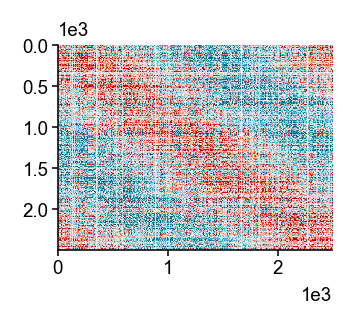

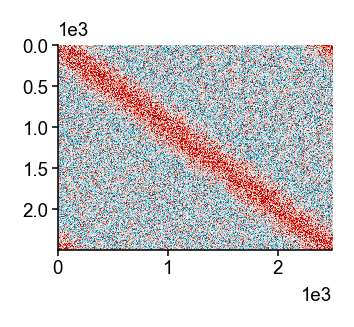

In [4]:
if os.path.exists(SPECTRA_CACHE):
    # Load the eigen/SVD results computed on the first run.
    _cache = np.load(SPECTRA_CACHE)
    J  = _cache['J'];   J2 = _cache['J2']
    w  = _cache['w'];   w2 = _cache['w2']
    U  = _cache['U'];   U2 = _cache['U2']
else:
    np.random.seed(45)

    #Generate TCs and J
    X, Phi = gen_tuning_curves_idealized(N_samples=N, N_theta=N_theta, beta=beta, scale=scale)
    J, _ = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)
    coms = data_driven.circular_com(data=Phi.T)
    order = np.argsort(coms)

    #sort
    X = X[:, order]
    Phi = Phi[:, order]
    J = J[:, order][order, :]

    #do SVD of J
    w = np.linalg.eigvals(J)
    U, s, Vt = np.linalg.svd(J)
    V = Vt.T

    #generate circulant matrix J2, with noise
    J2 = alpha * scipy.linalg.circulant(J_dmft) / N
    g = 0.1 #add noise
    np.random.seed(45)  # re-seed: upstream BLAS in sample_tcs may shift the cursor
    J2 += np.random.randn(N,N)*g/np.sqrt(N)

    #do eigvals and SVD of J2
    w2 = np.linalg.eigvals(J2)
    U2, s2, V2t = np.linalg.svd(J2)
    V2 = V2t.T

    # Write the cache exactly once, only on a fresh compute.
    np.savez(SPECTRA_CACHE, J=J, J2=J2, w=w, w2=w2, U=U, U2=U2,
             J_dmft=J_dmft, J_dmft_ft=J_dmft_ft, alpha=alpha)

#visualize J
vmax = np.std(J)*2
plt.imshow(J, vmin=-vmax, vmax=vmax, cmap=style.DIVERGING_CMAP)
plt.show()

#visualize J2
vmax = np.std(J2)*2
plt.imshow(J2, vmin=-vmax, vmax=vmax, cmap=style.DIVERGING_CMAP)
plt.show()

## Figure 6: spectra and eigenvector structure

Panels a/b show the two matrices; c compares the measured eigenvalue spectrum against DMFT theory; the eigenvalue-plane (d, e) and eigenvector-pair (f, g) scatters contrast `J` with `J2`; h is the ring-embedding schematic, placed last because the text discusses it last. Saves `disordered_vs_circulant_spectra.pdf`. A known eigenvector sign-flip can appear in the rightmost subplot when regenerating on a different BLAS.

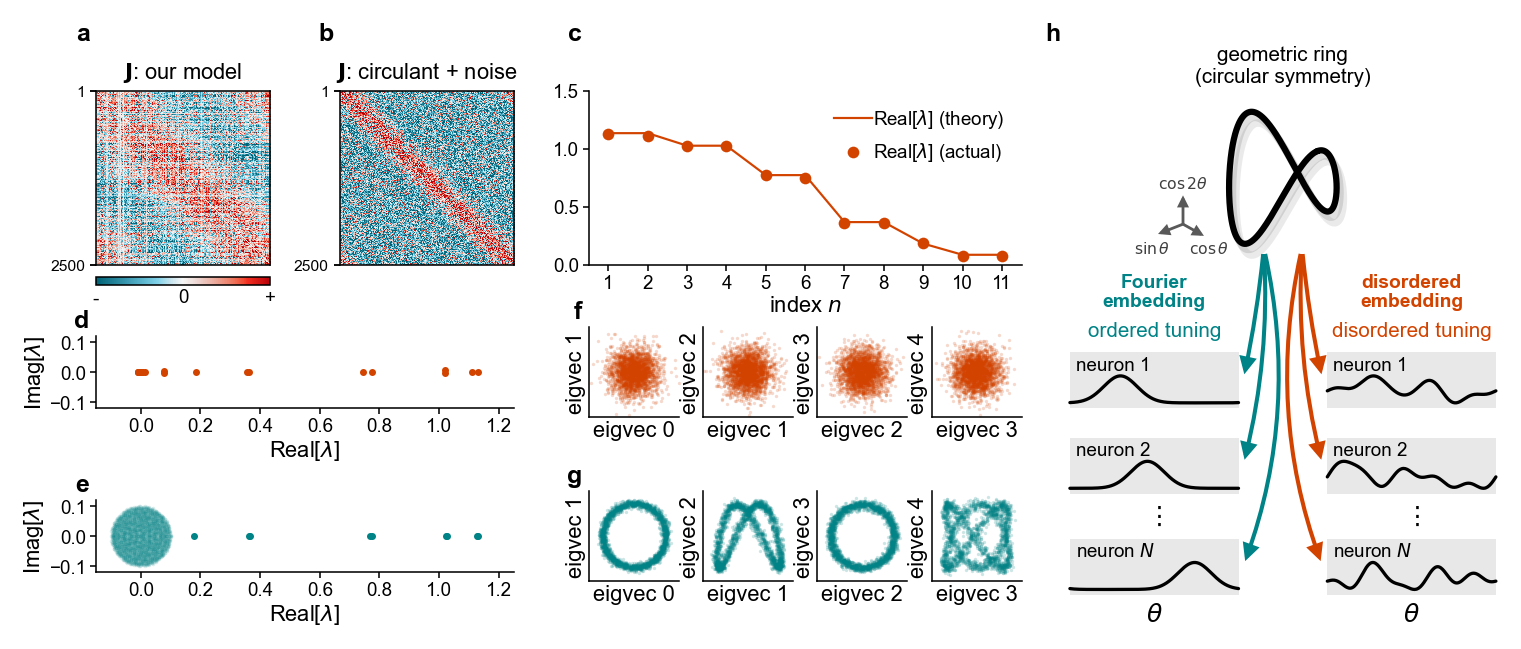

In [5]:
from ring import plot

# Double-column width (style.FULL_W = 183 mm). VERTICAL LAYOUT is set
# explicitly in INCHES below rather than left to the mosaic, because the mosaic
# left a band of dead whitespace between the upper half (schematic / heatmaps /
# spectra) and the lower half (eigenvalue planes and eigenvector scatters).
#
# The vertical design, all measured in inches:
#   _TOP_IN     heatmaps A/B and the spectra plot C share this top edge
#   _HM_SIDE    the heatmap square, which C's height is now matched to, so the
#               bottoms of A, B and C line up (the colorbar hangs below that line)
#   _ROW_H      nominal band height for one eigenvalue-plane / eigenvector-scatter
#               row; D is aligned with F and E with G, as two full-width rows
#   _C_TO_F_IN, _D_TO_E_IN
#               the two vertical CLEARANCES that were tuned by eye in the previous
#               layout. They are held FIXED here, so that widening the left column
#               (see the horizontal block below) cannot close a gap that was
#               already right. Everything else vertical is derived from them.
# Because every vertical quantity is pinned in INCHES DOWN FROM THE CANVAS TOP,
# _FIG_H is a pure bottom-margin control: raising it moves nothing and only adds
# white below. It is set so the bottom margin matches the top margin.
# The schematic is scaled to fit, never squashed: plot_embedding_schematic draws
# at a fixed aspect and the box width is derived from its height, so the drawing
# keeps its proportions.
_FIG_H    = 2.8125   # bottom-margin control only; see the note above
_TOP_IN   = 0.3203   # top edge of A, B, C, measured DOWN from the canvas top
_ROW_H    = 0.4986   # nominal band height for one lower row
_LTR_IN   = 0.116    # top-row panel-letter baseline, DOWN from the canvas top
_A_HEAD_IN = 0.115   # headroom above the schematic for its overhanging caption
_C_TO_F_IN = 0.27658  # A/B/C bottom line -> top of the F scatter row
_D_TO_E_IN = 0.41191  # bottom of the D eigenvalue plane -> top of the E plane

fig, axes = plt.subplot_mosaic(mosaic="""
AAAABBBB-CCCCCCCC.ZZZZZZZZ
AAAABBBB-CCCCCCCC.ZZZZZZZZ
JJJJJJJJ-DDFFHHLL.ZZZZZZZZ
KKKKKKKK-EEGGIIMM.ZZZZZZZZ
""", figsize=(style.FULL_W, _FIG_H))
fig.subplots_adjust(wspace=0., left=0.0322, right=0.9422, top=0.95, bottom=0.1, hspace=0.4)
axes['-'].set_visible(False)
_fw, _fh = fig.get_figwidth(), fig.get_figheight()

# ---------------------------------------------------------------------------
# HORIZONTAL LAYOUT. The figure reads as three column GROUPS:
#   G1  heatmaps A, B above the eigenvalue planes D, E
#   G2  the spectrum C above the eigenvector-scatter rows F, G
#   G3  the schematic H
# Widths here are CONTENT widths, measured LEFT SPINE TO RIGHT SPINE (not the ink
# bounding box, which is dominated by the rotated y-labels). The budget is
#     _W_L + _GAP_L + _W_R + _GAP_R + _W_R + 2*_PAD == 1,
# with the outer left and right pads equal.
#
# The three groups are deliberately NOT equal. An earlier equal-width, equal-gap
# version read as flat, because the left group is two small squares while each of
# the other two is one large object. So the C -> H gap is pulled in to 0.6 of the
# A/B -> C gap, and the 3.39 mm that frees up is handed to C and H, which stay
# equal to each other and end up wider than the A/B group. The spacing then READS
# as even although it is measurably asymmetric.
#
# Every panel position below is derived from these numbers, and every
# aspect-constrained axes is given a box that ALREADY satisfies its aspect, so
# apply_aspect never silently shrinks a box out from under the arithmetic.
_PAD   = 0.067175                                # 12.293 mm outer pad, both sides
_GAP_L = 0.046290                                #  8.471 mm, A/B group -> C
_GAP_R = 0.6 * _GAP_L                            #  5.083 mm, C -> H
_W_L   = (1.0 - 2 * _PAD - 2 * _GAP_L) / 3.0     # 47.157 mm, A/B group (unchanged)
_W_R   = (1.0 - 2 * _PAD - _GAP_L - _GAP_R - _W_L) / 2.0   # 48.851 mm, C and H
_X_G1  = _PAD
_X_G2  = _PAD + _W_L + _GAP_L
_X_G3  = 1.0 - _PAD - _W_R

# G1 internals: two square heatmaps separated by _HM_GAP (room for panel B's
# y-ticks). The heatmap SIDE is whatever makes A + gap + B come to _W_L, and
# because the heatmaps are square that side is also the top block's height.
_HM_GAP  = 0.043
_HM_W    = (_W_L - _HM_GAP) / 2
_HM_SIDE = _HM_W * _fw
_HM_H    = _HM_SIDE / _fh
_HM_X0   = _X_G1
_HM_TOP  = (_FIG_H - _TOP_IN) / _FIG_H

# G2 internals: four square eigenvector-scatter panels per row, spanning exactly
# _W_R so the rows line up with panel C's spines.
_gap = 0.015                              # figure-fraction gap between scatters
_SC_W = (_W_R - 3 * _gap) / 4
_SC_H = _SC_W * _fw / _fh                 # square

# The eigenvalue planes D/E span the whole LEFT group; aspect=1 with a 1.4-wide
# by 0.24-tall data box fixes their height once their width is chosen.
_EV_H = _W_L * _fw * (0.24 / 1.4) / _fh

# Vertical placement of the two lower rows, derived from the fixed clearances.
_H_ROW      = _ROW_H / _FIG_H
_TOPBLK_BOT = _HM_TOP - _HM_H             # shared bottom of A, B and C
_F_TOP      = _TOPBLK_BOT - _C_TO_F_IN / _FIG_H
_Y_UPPER    = _F_TOP - (_H_ROW + _SC_H) / 2          # band bottom, D / F row
_Y_LOWER    = _Y_UPPER - (_D_TO_E_IN / _FIG_H + _EV_H)  # band bottom, E / G row

# panel H: ring-embedding schematic (former standalone figure). It occupies the
# full-height RIGHT column, because the text discusses it last. Drawn at a fixed
# design aspect (width/height ~ 0.77), so the drawing is scaled, never squashed.
# It is WIDTH-driven, since its width is _W_R like panel C; the height follows,
# and the box is hung from the headroom line so the "geometric ring" caption,
# which overhangs the axes, is not clipped.
_A_ASPECT  = 0.77
_draw_w_in = _W_R * _fw
_draw_h_in = _draw_w_in / _A_ASPECT
assert _draw_h_in <= _FIG_H - _A_HEAD_IN, "schematic no longer fits the canvas"
_A_H = _draw_h_in / _FIG_H
axes['Z'].set_position([_X_G3, (_FIG_H - _A_HEAD_IN) / _FIG_H - _A_H, _W_R, _A_H])
plot.plot_embedding_schematic(axes['Z'], aspect=_A_ASPECT)

# matrices are N x N neurons; give the heatmaps neuron-index axes (1..N) so the
# reader can read off the neuron count. Images are downsampled for display, but
# the extent still spans the full 1..N neuron range.
N_neurons = J.shape[0]
vmax = np.std(J)*2
im1 = axes['A'].imshow(J[::5,::5], vmin=-vmax, vmax=vmax, cmap=style.DIVERGING_CMAP, aspect=1,
                       interpolation='nearest', extent=[1, N_neurons, N_neurons, 1])
# labels sit a little above the heatmaps (pad) for breathing room
axes['A'].set_title("$\\mathbf{J}$: our model", pad=4)

vmax2 = np.std(J2)*2
im2 = axes['B'].imshow(J2[::5,::5], vmin=-vmax, vmax=vmax2, cmap=style.DIVERGING_CMAP, aspect=1,
                       interpolation='nearest', extent=[1, N_neurons, N_neurons, 1])
axes['B'].set_title("$\\mathbf{J}$: circulant + noise", pad=4)

# Both heatmaps share the same 1..N neuron scale and are drawn at the SAME size,
# so BOTH carry the 1 / N neuron y-ticks (panel C's ticks were restored per
# review). Ticks are 5 pt, drawn on the left of each heatmap.
for ax in (axes['A'], axes['B']):
    ax.set_xticks([])
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.set_yticks([1, N_neurons])
    ax.set_yticklabels(["1", str(N_neurons)])
    ax.tick_params(axis='y', length=2, width=0.6, labelsize=5, pad=1.5)

axes['A'].set_position([_HM_X0, _HM_TOP - _HM_H, _HM_W, _HM_H])
axes['B'].set_position([_HM_X0 + _HM_W + _HM_GAP, _HM_TOP - _HM_H, _HM_W, _HM_H])

# Panel C (spectra, axes['C']): squared off to the heatmaps. It shares their top
# edge AND their height, so the bottoms of A, B and C all land on one line. Its
# WIDTH is the wider right-group budget _W_R. The colorbar hangs below that line,
# under panel A only, and is deliberately not counted in the alignment.
axes['C'].set_position([_X_G2, _HM_TOP - _HM_H, _W_R, _HM_H])

# Colorbar: the house-standard thin bar attached to the single "our model" panel
# (panel A). Placed in its own axis directly below the heatmap so it does NOT
# steal height from the heatmap (which would make panel A smaller than panel B).
# im1's clim is symmetric (+/- vmax), so the '0' tick lands on the white centre
# of the diverging map; keep the '-','0','+' labels at 6 pt.
_vb = np.abs(im1.get_clim()).max()
_CB_GAP, _CB_H = 0.020, 0.013
_ap = axes['A'].get_position()
cax_B = fig.add_axes([_ap.x0, _ap.y0 - _CB_GAP - _CB_H, _ap.width, _CB_H])
cbar_B = fig.colorbar(im1, cax=cax_B, orientation='horizontal',
                      ticks=[-_vb, 0, _vb])
cbar_B.set_ticklabels(['-', '0', '+'])
cbar_B.outline.set_linewidth(0.5)
cbar_B.ax.tick_params(length=0, pad=1, labelsize=6, width=0.5)


ax_spectra = axes['C']
idx = np.arange(11)+1
#plot SVs

# plot eigvals (CONVENTIONS_v3 pattern 2 -- theory vs measurement of the same
# quantity, same colour, distinguished by TYPE): analytic theory is a SOLID
# black line, the measured eigenvalues are filled black CIRCLE markers on top.
# Panel C is OUR model's spectrum, so it takes style.J_COLOR like panels D and F.
# Theory vs measurement of the same quantity is convention pattern 2: same colour,
# distinguished by TYPE (solid line for theory, filled markers for measurement).
ax_spectra.plot(idx, alpha*np.sort(J_dmft_ft.real)[::-1][:len(idx)], label='Real[$\\lambda$] (theory)', c=style.J_COLOR, ls='-')
ax_spectra.scatter(idx, np.sort(w.real)[::-1][:len(idx)], marker='o', s=14, lw=0, label='Real[$\\lambda$] (actual)', c=style.J_COLOR, zorder=3)

ax_spectra.legend(handletextpad=0.1) #, fontsize=6)
ax_spectra.set_ylim(0, 1.5)
ax_spectra.set_xticks(idx)
ax_spectra.set_xlabel("index $n$")

j_color = style.J_COLOR
j2_color = style.J2_COLOR

top_axes = (axes['D'], axes['F'], axes['H'], axes['L'])
for i, ax in enumerate(top_axes):
    ax.scatter(U[:, i], U[:, i+1], lw=0, s=1.15, alpha=0.20, c=j_color, clip_on=False)
    ax.set_xlabel("eigvec {}".format(i))
    ax.set_ylabel("eigvec {}".format(i+1))
    ax.set_xlim(-0.075, 0.075)
    ax.set_ylim(-0.075, 0.075)

bottom_axes = (axes['E'], axes['G'], axes['I'], axes['M'])
for i, ax in enumerate(bottom_axes):
    ax.scatter(U2[:, i], U2[:, i+1], lw=0, s=1.15, alpha=0.20, c=j2_color, clip_on=False)
    ax.set_xlabel("eigvec {}".format(i))
    ax.set_ylabel("eigvec {}".format(i+1))
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)

for ax in top_axes + bottom_axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect(1)

# Lay each scatter row out across the FULL right-group width, with a fixed gap
# between panels so every rotated y-label sits clear of its neighbour. Boxes are
# square by construction, and each row is centred in its band, exactly as before.
for _row, _yb in ((top_axes, _Y_UPPER), (bottom_axes, _Y_LOWER)):
    _y0 = _yb + (_H_ROW - _SC_H) / 2
    for _j, _ax in enumerate(_row):
        _ax.set_position([_X_G2 + _j * (_SC_W + _gap), _y0, _SC_W, _SC_H])

# Eigenvalue planes D/E: full LEFT-group width, centred in the same two bands, so
# the eigenvalue plane and the eigenvector scatters read as two aligned bands.
for _ax, _yb in ((axes['J'], _Y_UPPER), (axes['K'], _Y_LOWER)):
    _ax.set_position([_X_G1, _yb + (_H_ROW - _EV_H) / 2, _W_L, _EV_H])

for i, (wc, ax) in enumerate(zip((w,w2), (axes['J'], axes['K']))):
    color = j_color if i == 0 else j2_color
    if i == 0:
        ax.scatter(wc.real, wc.imag, lw=0, s=5, alpha=1, c=color)
    else:
        # Split the dense bulk (the disk near the origin) from the real-axis
        # outliers: draw the bulk with small translucent markers so its internal
        # density is visible instead of a solid blob, and keep the outliers solid
        # so they stay clearly readable.
        outlier = wc.real > 0.15
        bulk = ~outlier
        ax.scatter(wc.real[bulk], wc.imag[bulk], lw=0, s=1.35, alpha=0.13, c=color)
        ax.scatter(wc.real[outlier], wc.imag[outlier], lw=0, s=5, alpha=1, c=color)
    ax.set_ylim(-0.12, 0.12)
    ax.set_xlim(-0.15, 1.25)
    ax.set_aspect(1.)
    ax.set_xlabel("Real[$\\lambda$]")
    ax.set_ylabel("Imag[$\\lambda$]")


# Panel letters: house style is 8 pt bold (style.panel_letter's typography;
# its docstring directs figure-level placement to fig.text). Letters are aligned
# to shared baselines/verticals per row and column.
def _plabel(x, y, letter):
    fig.text(x, y, letter, ha='right', va='bottom', size=8, weight='bold')

# top row (A, B, C, and the schematic's H): one common baseline, pinned to a fixed
# offset from the canvas top rather than to the tallest panel, so that re-scaling
# the schematic does not drag the letters around. The letters sit at the far left
# of each panel, clear of the schematic's centred caption.
_y_top = (_FIG_H - _LTR_IN) / _FIG_H
for _k, _l in [('A', 'a'), ('B', 'b'), ('C', 'c'), ('Z', 'h')]:
    _plabel(axes[_k].get_position().x0 - 0.004, _y_top, _l)

# left column eigenvalue-plane letters (D over J-plane, E over K-plane): common x
_x_DE = axes['J'].get_position().x0 - 0.004
_plabel(_x_DE, axes['J'].get_position().y1 + 0.006, 'd')
_plabel(_x_DE, axes['K'].get_position().y1 + 0.006, 'e')

# middle block eigenvector-scatter letters (F over top row, G over bottom row): common x
_x_FG = axes['D'].get_position().x0 - 0.004
_plabel(_x_FG, axes['D'].get_position().y1 + 0.006, 'f')
_plabel(_x_FG, axes['E'].get_position().y1 + 0.006, 'g')

if SAVE_FIGURES:
    plt.savefig("../figures/disordered_vs_circulant_spectra.pdf", dpi=400)